In [14]:
import pandas as pd
from pathlib import Path

# Path: should be adjusted based on the actual location of the dataset
file_path = Path("../data/LD2011_2014.txt")


df = pd.read_csv(
    file_path,
    sep=";",
    decimal=",",
    parse_dates=[0]
)

# Rename timestamp column
df.rename(columns={df.columns[0]: "timestamp"}, inplace=True)

# Set timestamp as index
df.set_index("timestamp", inplace=True)

# Aggregate demand
aggregate_demand = df.sum(axis=1) / 1e6
df_aggregate = aggregate_demand.to_frame(name="aggregate_demand_MW")

# Basic information about the dataset
print("Original dataset shape:", df.shape)
print("Aggregate dataset shape:", df_aggregate.shape)

df_aggregate.head()

Original dataset shape: (140256, 370)
Aggregate dataset shape: (140256, 1)


,aggregate_demand_MW
timestamp,
2011-01-01 00:15:00,0.068513
2011-01-01 00:30:00,0.069180
2011-01-01 00:45:00,0.069365
2011-01-01 01:00:00,0.068350
2011-01-01 01:15:00,0.066167


A daily version is saved to make it easier for ARIMA modeling:

In [15]:
df_aggregate_daily = df_aggregate.resample("D").sum()

print(df_aggregate_daily.shape)
df_aggregate_daily.head()

(1462, 1)


,aggregate_demand_MW
timestamp,
2011-01-01,6.852976
2011-01-02,11.141346
2011-01-03,11.249072
2011-01-04,11.467863
2011-01-05,11.521747


#### Exploratory Data Analysis (EDA)
##### Plot series

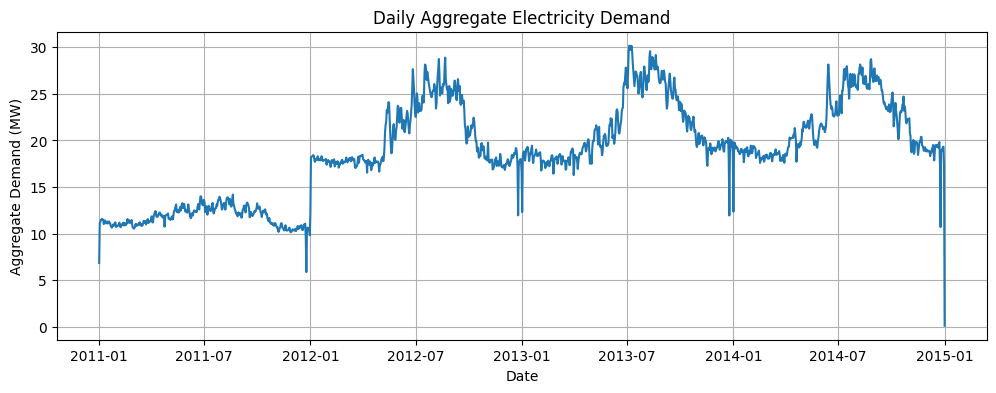

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df_aggregate_daily.index, df_aggregate_daily["aggregate_demand_MW"])
plt.title("Daily Aggregate Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Aggregate Demand (MW)")
plt.grid(True)
plt.show()

##### Evaluating 2011 data in detail

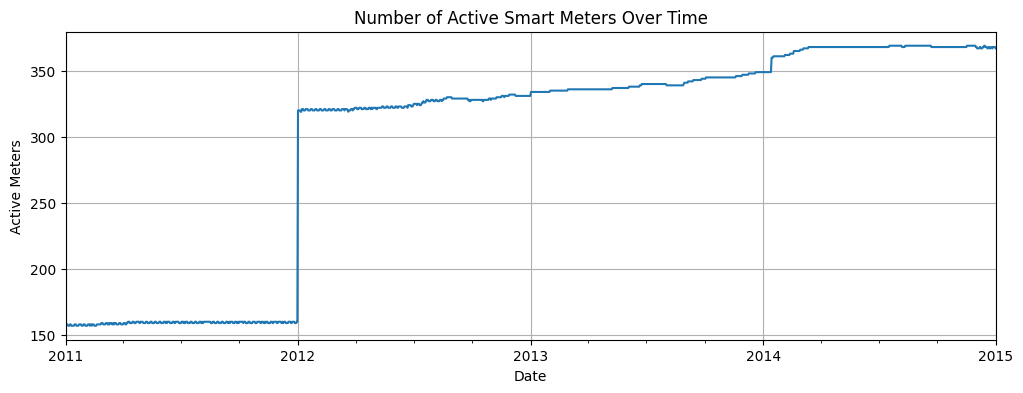

In [25]:
active_meters_daily = (df > 0).resample("D").sum()
active_meters_count = (active_meters_daily > 0).sum(axis=1)

active_meters_count.plot(figsize=(12, 4))
plt.title("Number of Active Smart Meters Over Time")
plt.xlabel("Date")
plt.ylabel("Active Meters")
plt.grid(True)
plt.show()

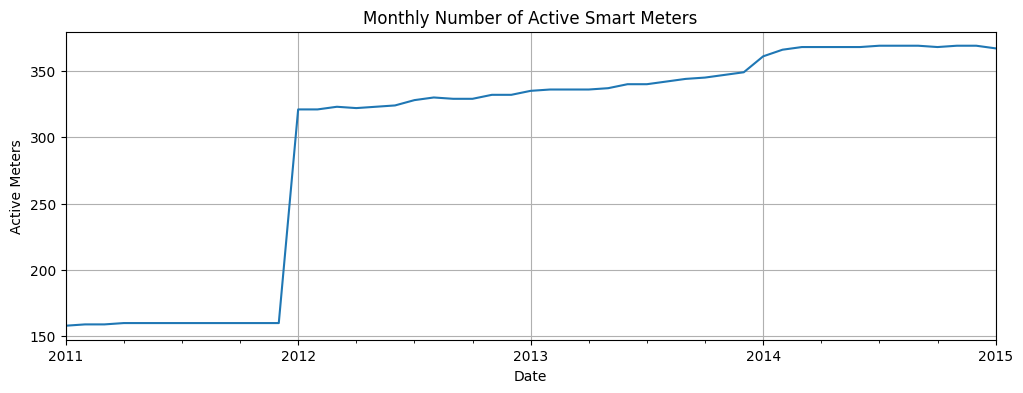

In [27]:
monthly_active = (df > 0).resample("ME").sum()
monthly_active_count = (monthly_active > 0).sum(axis=1)

monthly_active_count.plot(figsize=(12, 4))
plt.title("Monthly Number of Active Smart Meters")
plt.xlabel("Date")
plt.ylabel("Active Meters")
plt.grid(True)
plt.show()

##### Trend/seasonality

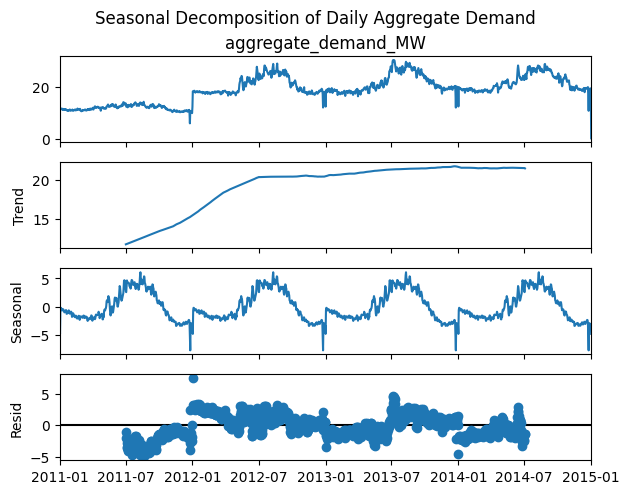

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df_aggregate_daily["aggregate_demand_MW"],
    model="additive",
    period=365
)

decomposition.plot()
plt.suptitle("Seasonal Decomposition of Daily Aggregate Demand", y=1.02)
plt.show()

##### Summary stats

In [18]:
summary_stats = df_aggregate_daily["aggregate_demand_MW"].describe()

print(summary_stats)

print("\nMissing values:")
print(df_aggregate_daily.isna().sum())

print("\nDate range:")
print(df_aggregate_daily.index.min(), "to", df_aggregate_daily.index.max())

count    1462.000000
mean       18.760626
std         5.066878
min         0.124214
25%        13.846884
50%        18.683429
75%        22.277740
max        30.168595
Name: aggregate_demand_MW, dtype: float64

Missing values:
aggregate_demand_MW    0
dtype: int64

Date range:
2011-01-01 00:00:00 to 2015-01-01 00:00:00


##### Stationarity check - visual

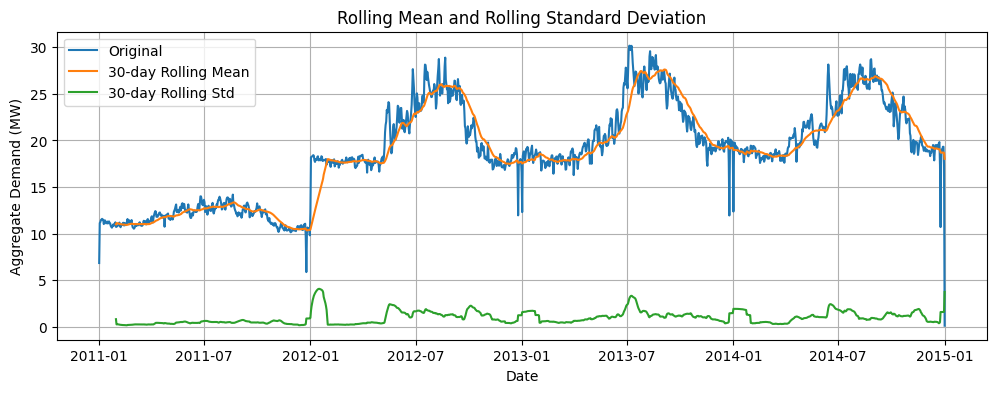

In [19]:
rolling_mean = df_aggregate_daily["aggregate_demand_MW"].rolling(window=30).mean()
rolling_std = df_aggregate_daily["aggregate_demand_MW"].rolling(window=30).std()

plt.figure(figsize=(12, 4))
plt.plot(df_aggregate_daily["aggregate_demand_MW"], label="Original")
plt.plot(rolling_mean, label="30-day Rolling Mean")
plt.plot(rolling_std, label="30-day Rolling Std")
plt.title("Rolling Mean and Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Aggregate Demand (MW)")
plt.legend()
plt.grid(True)
plt.show()

##### Stationarity check - ADF test

In [20]:
from statsmodels.tsa.stattools import adfuller

series = df_aggregate_daily["aggregate_demand_MW"].dropna()

adf_result = adfuller(series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value}")

ADF Statistic: -1.6411820344126677
p-value: 0.4616432123372719
Critical Values:
  1%: -3.434899302257815
  5%: -2.8635492080466607
  10%: -2.567839687982253


##### Differencing if needed


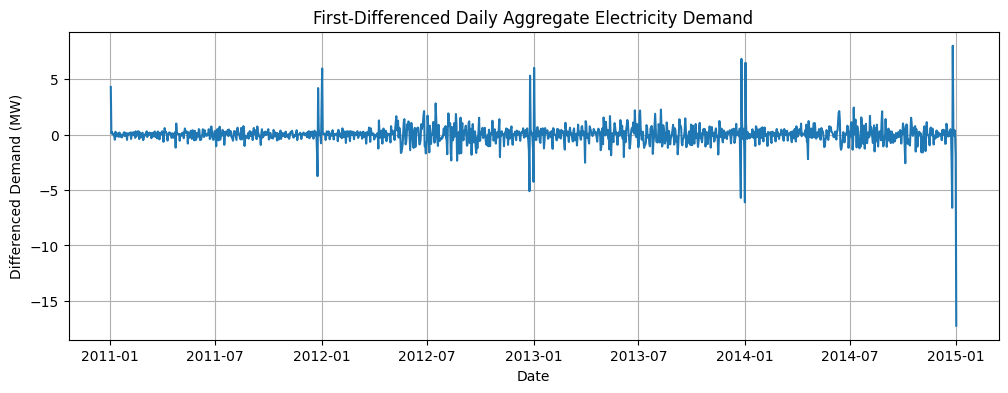

In [21]:
df_aggregate_daily["diff_1"] = df_aggregate_daily["aggregate_demand_MW"].diff()

plt.figure(figsize=(12, 4))
plt.plot(df_aggregate_daily["diff_1"])
plt.title("First-Differenced Daily Aggregate Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Differenced Demand (MW)")
plt.grid(True)
plt.show()

##### ADF Test after differencing

In [22]:
diff_series = df_aggregate_daily["diff_1"].dropna()

adf_diff_result = adfuller(diff_series)

print("ADF Statistic:", adf_diff_result[0])
print("p-value:", adf_diff_result[1])
print("Critical Values:")
for key, value in adf_diff_result[4].items():
    print(f"  {key}: {value}")

ADF Statistic: -8.273439815159433
p-value: 4.725442332913268e-13
Critical Values:
  1%: -3.434899302257815
  5%: -2.8635492080466607
  10%: -2.567839687982253


##### ACF / PACF — original series

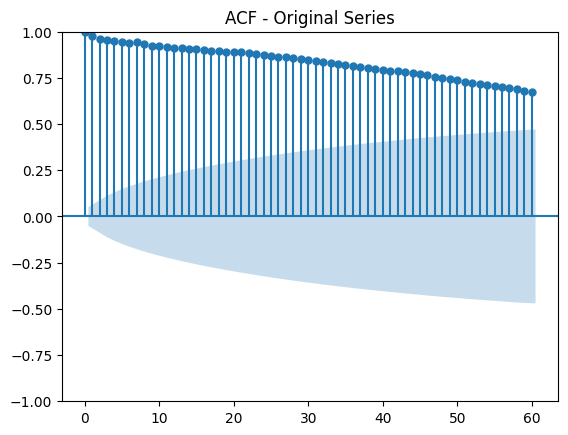

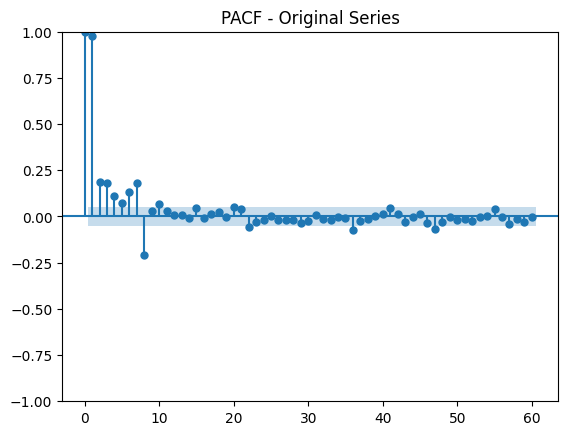

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df_aggregate_daily["aggregate_demand_MW"].dropna()

plot_acf(series, lags=60)
plt.title("ACF - Original Series")
plt.show()

plot_pacf(series, lags=60, method="ywm")
plt.title("PACF - Original Series")
plt.show()

##### ACF / PACF — differenced series

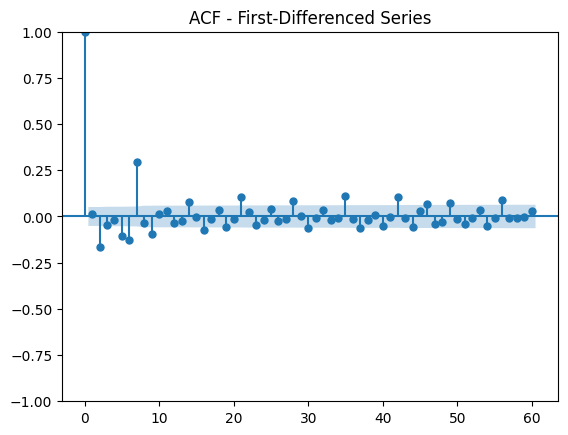

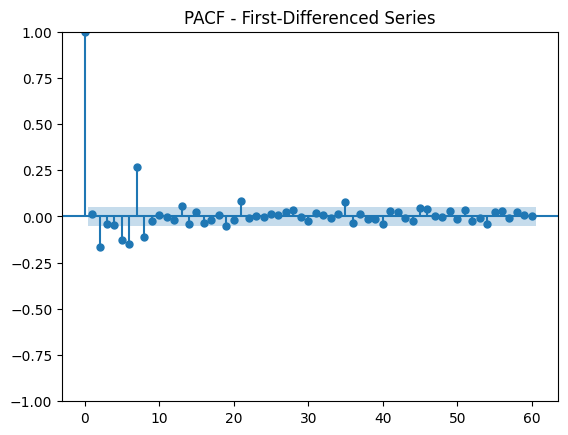

In [24]:
diff_series = df_aggregate_daily["diff_1"].dropna()

plot_acf(diff_series, lags=60)
plt.title("ACF - First-Differenced Series")
plt.show()

plot_pacf(diff_series, lags=60, method="ywm")
plt.title("PACF - First-Differenced Series")
plt.show()